In [92]:
import statsmodels.api as sm
import pandas as pd
from datasets import Dataset


# Load the file from a public URL, since we had issues with loading from datasets
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/refs/heads/master/BostonHousing.csv')

# convert to a dataset
data = Dataset.from_pandas(df)
#print(data.info)

In [93]:
import numpy as np
import pandas as pd

# Since this dataset doesn't have a "target", extract features (all columns except 'medv') and target ('medv') from pandas_df, as per random googling.
features_df = df.drop(columns=['medv'])
target = df['medv']


In [94]:
X = df["rm"]
y = df["medv"]


# Fit and make the predictions by the model
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.901
Model:                            OLS   Adj. R-squared (uncentered):              0.901
Method:                 Least Squares   F-statistic:                              4615.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                   3.74e-256
Time:                        02:13:21   Log-Likelihood:                         -1747.1
No. Observations:                 506   AIC:                                      3496.
Df Residuals:                     505   BIC:                                      3500.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             3.6534      0.054     67.930      0.000       3.548       3.759
==============================================================================
Omnibus:                       83.295   Durbin-Watson:                   0.493
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              152.507
Skew:                           0.955   Prob(JB):                     7.65e-34
Kurtosis:                       4.894   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [95]:
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.49e-74
Time:                        02:13:21   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.6706      2.650    -13.084      0.000     -39.877     -29.465
rm             9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [96]:
X = df[["rm", "lstat"]] #
y = target ## target is already set to medv in cell two above

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.948
Model:                            OLS   Adj. R-squared (uncentered):              0.948
Method:                 Least Squares   F-statistic:                              4637.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                        0.00
Time:                        02:13:21   Log-Likelihood:                         -1582.9
No. Observations:                 506   AIC:                                      3170.
Df Residuals:                     504   BIC:                                      3178.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             4.9069      0.070     69.906      0.000       4.769       5.045
lstat         -0.6557      0.031    -21.458      0.000      -0.716      -0.596
==============================================================================
Omnibus:                      145.153   Durbin-Watson:                   0.834
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              442.157
Skew:                           1.351   Prob(JB):                     9.70e-97
Kurtosis:                       6.698   Cond. No.                         4.72
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4. Visualize actual vs. predicted values

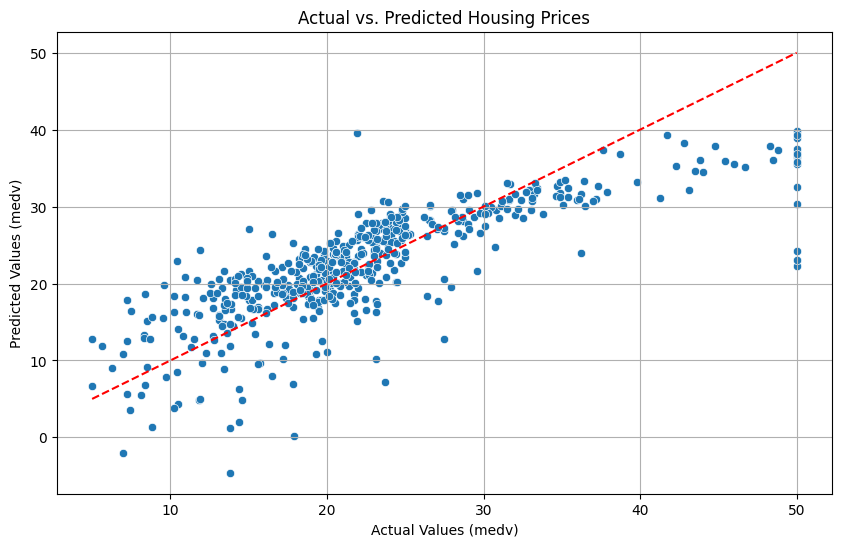

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

## Nifty graph, courtesy of Gemini
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=predictions)
plt.xlabel('Actual Values (medv)')
plt.ylabel('Predicted Values (medv)')
plt.title('Actual vs. Predicted Housing Prices')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--') # Add a perfect prediction line
plt.grid(True)
plt.show()

## The graph demonstrates that with two variables (number of rooms and " % lower status of the population") used
## to predict median house value, the predictions appear to be fairly accurate for the lower median
## values and less accurate for the higher median house values

In [98]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 30.52
R-squared: 0.64


In [99]:
X = df[["rm", "lstat", "ptratio"]] # let's throw in the "pupil-teacher ratio by town" to see what happens
y = target

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

### all three variables ["rm", "lstat", "ptratio"] have a p-value of 0.000, which means that they are statistically significant


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              3335.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                        0.00
Time:                        02:13:22   Log-Likelihood:                         -1564.1
No. Observations:                 506   AIC:                                      3134.
Df Residuals:                     503   BIC:                                      3147.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             6.2433      0.225     27.692      0.000       5.800       6.686
lstat         -0.4919      0.040    -12.439      0.000      -0.570      -0.414
ptratio       -0.5714      0.092     -6.215      0.000      -0.752      -0.391
==============================================================================
Omnibus:                      196.409   Durbin-Watson:                   0.888
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1133.974
Skew:                           1.593   Prob(JB):                    5.76e-247
Kurtosis:                       9.606   Cond. No.                         24.3
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

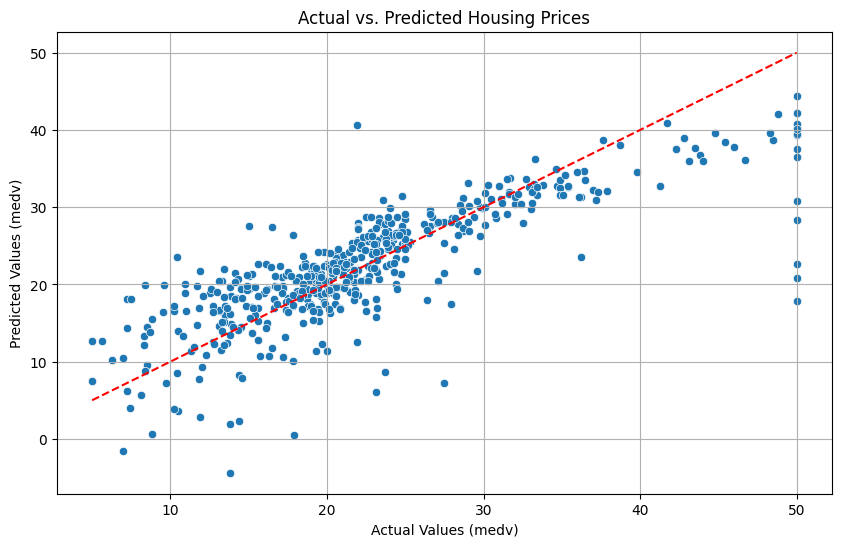

In [100]:
## Another nifty graph
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=predictions)
plt.xlabel('Actual Values (medv)')
plt.ylabel('Predicted Values (medv)')
plt.title('Actual vs. Predicted Housing Prices')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--') # Add a perfect prediction line
plt.grid(True)
plt.show()

In [101]:
X = df[["rm", "lstat", "ptratio", "age"]] # add the building's age
y = target

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

## the coef value of .0108 for the "age" variable is significantly smaller than the coefs
## for the other variables considered. Also, the p-value is 0.317 is larger than the "common significance level"
## of 0.05. Therefore, age does not have a significant influence on the median house value.

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              2501.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                        0.00
Time:                        02:13:22   Log-Likelihood:                         -1563.6
No. Observations:                 506   AIC:                                      3135.
Df Residuals:                     502   BIC:                                      3152.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             6.1880      0.232     26.660      0.000       5.732       6.644
lstat         -0.5203      0.049    -10.696      0.000      -0.616      -0.425
ptratio       -0.5733      0.092     -6.234      0.000      -0.754      -0.393
age            0.0108      0.011      1.002      0.317      -0.010       0.032
==============================================================================
Omnibus:                      185.877   Durbin-Watson:                   0.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1005.677
Skew:                           1.516   Prob(JB):                    4.17e-219
Kurtosis:                       9.205   Cond. No.                         81.2
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [102]:
X = df[["rm", "lstat", "ptratio", "rad"]] # add the index of accessibility to the radial highways
y = target

model = sm.OLS(y, X).fit()

model.summary()

## "rad" or the index of accessibility to the radial highways does not have a significant
## influence on the median value (coef -0.0360, p-value 0.263)

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              2503.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                        0.00
Time:                        02:13:22   Log-Likelihood:                         -1563.5
No. Observations:                 506   AIC:                                      3135.
Df Residuals:                     502   BIC:                                      3152.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             6.2009      0.229     27.131      0.000       5.752       6.650
lstat         -0.4770      0.042    -11.430      0.000      -0.559      -0.395
ptratio       -0.5483      0.094     -5.820      0.000      -0.733      -0.363
rad           -0.0360      0.032     -1.120      0.263      -0.099       0.027
==============================================================================
Omnibus:                      213.028   Durbin-Watson:                   0.881
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1324.955
Skew:                           1.726   Prob(JB):                    1.95e-288
Kurtosis:                      10.136   Cond. No.                         27.1
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [103]:
X = df[["rm", "lstat", "ptratio", "nox"]] # add the nitric oxides concentration (parts per 10 million)
y = target

model = sm.OLS(y, X).fit()

model.summary()

## relatively small coef for the nox variable (0.2438) and a relatively high standard error
## mean that there is a high degree of uncertainty about the effect of this variable on the medv

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              2496.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):                        0.00
Time:                        02:13:22   Log-Likelihood:                         -1564.1
No. Observations:                 506   AIC:                                      3136.
Df Residuals:                     502   BIC:                                      3153.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rm             6.2317      0.255     24.436      0.000       5.731       6.733
lstat         -0.4949      0.050     -9.924      0.000      -0.593      -0.397
ptratio       -0.5727      0.093     -6.156      0.000      -0.756      -0.390
nox            0.2438      2.496      0.098      0.922      -4.660       5.148
==============================================================================
Omnibus:                      195.397   Durbin-Watson:                   0.889
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1121.049
Skew:                           1.586   Prob(JB):                    3.69e-244
Kurtosis:                       9.566   Cond. No.                         250.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [104]:
from sklearn import linear_model
X = features_df # Use features_df which correctly excludes 'medv'
y = target

lm = linear_model.LinearRegression()
model = lm.fit(X,y)
predictions = lm.predict(X)
print(predictions[0:5])

lm.score(X,y)

[30.00384338 25.02556238 30.56759672 28.60703649 27.94352423]


0.7406426641094095

In [105]:
print("\nCoefficients mapped to attributes (ascending order):")
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lm.coef_})
coef_df_sorted = coef_df.sort_values(by='coefficient', ascending=True)
for index, row in coef_df_sorted.iterrows():
    print(f"{row['feature']}: {row['coefficient']}")

## the highest coefs according to this model are:
# nox: -17.76661122830015 (high stderr according to the previous model)
# dis: -1.4755668456002575
# rad: 0.30604947898517637
# chas: 2.6867338193449513
# rm: 3.8098652068092065

## the sklearn linear regression model does not compute the standard error


Coefficients mapped to attributes (ascending order):
nox: -17.76661122830015
dis: -1.4755668456002575
ptratio: -0.9527472317072896
lstat: -0.5247583778554882
crim: -0.1080113578367983
tax: -0.012334593916574842
age: 0.0006922246403473038
b: 0.009311683273793801
indus: 0.02055862636707091
zn: 0.04642045836688072
rad: 0.30604947898517637
chas: 2.6867338193449513
rm: 3.8098652068092065
